# Quantitative and Qualitative Analysis: Monocular Depth Estimation

## Objective
This section focuses on implementing and analyzing **monocular depth estimation** using a pre-trained deep learning model.

## Step 1: Setup and Dataset Preparation
- Install required packages (`gdown`, etc.)
- Download the CARLA dataset (RGB + ground truth depth maps).
- Extract dataset and prepare folder structure.
- Clone Depth-Anything-V2 repository and install dependencies.
- Download pre-trained weights for inference.


In [3]:
!pip install -q gdown
import gdown, zipfile, os

# Download dataset
file_id = "1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq"
output = "dataset.zip"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("dataset")

# Clone repository & install
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd Depth-Anything-V2
!pip install -r requirements.txt


Downloading...
From (original): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq
From (redirected): https://drive.google.com/uc?id=1xYiNbsxqzvsNKuhvHQaTL1y1Oceq0rzq&confirm=t&uuid=f3985aba-93d4-45ca-943c-0ae6b7100c53
To: /content/dataset.zip
100%|██████████| 280M/280M [00:01<00:00, 248MB/s]


fatal: destination path 'Depth-Anything-V2' already exists and is not an empty directory.
/content/Depth-Anything-V2


In [4]:
# Download pre-trained weights
!mkdir -p checkpoints
!gdown https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth \
    -O checkpoints/depth_anything_v2_vitl.pth


Downloading...
From: https://huggingface.co/depth-anything/Depth-Anything-V2-Large/resolve/main/depth_anything_v2_vitl.pth
To: /content/Depth-Anything-V2/checkpoints/depth_anything_v2_vitl.pth
100% 1.34G/1.34G [00:05<00:00, 240MB/s]


## Step 2: Model Initialization
- Load the Depth-Anything-V2 (ViT-Large) pre-trained model.
- Load weights into the model.
- Move the model to GPU (if available) or CPU.

## Step 3: Preprocessing
- Resize input images to 518×518 pixels.
- Normalize pixel values to [-1, 1].


In [5]:
import torch
from torchvision import transforms
from depth_anything_v2.dpt import DepthAnythingV2
import cv2, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model
model = DepthAnythingV2(
    encoder='vitl',
    features=256,
    out_channels=[256, 512, 1024, 1024]
)
model.load_state_dict(torch.load("checkpoints/depth_anything_v2_vitl.pth", map_location=device))
model.to(device).eval()

# Preprocessing
transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(mean=0.5, std=0.5)
])

# Paths
input_folder = "/content/dataset/3DCV00_data/data/images/left"
gt_folder = "/content/dataset/3DCV00_data/data/images/gt_depth"
output_folder = "/content/predicted_depth"
os.makedirs(output_folder, exist_ok=True)


Using device: cuda


## **Depth Estimation – Inference & Evaluation**

### **Step 4: Inference and Post-processing**

* Predict depth maps for all input images using the trained model.
* Save predicted depth maps (uint8 normalized) for visualization only.
* Flip predicted depth (`1 - pred_norm`) to align with ground truth orientation (for monocular models).
* Normalize both predicted and ground truth depth maps to a global scale (`MAX_DEPTH = 80m`).

### **Step 5: Quantitative Evaluation**

* Compute depth estimation metrics:

  * **Mean Absolute Error (MAE)**
  * **Root Mean Squared Error (RMSE)**
  * **Absolute Relative Error (AbsRel)**



In [ ]:
from tqdm import tqdm
import os
import cv2
import numpy as np
from PIL import Image
import torch

# ---- Parameters ----
MAX_DEPTH = 80.0  # Global depth scale (CARLA ~80m)
device = "cuda" if torch.cuda.is_available() else "cpu"

MAEs, RMSEs, AbsRels = [], [], []

for fname in tqdm(os.listdir(input_folder)):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # ---- 1. Predict Depth ----
    img = Image.open(os.path.join(input_folder, fname)).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(input_tensor).squeeze().cpu().numpy().astype(np.float32)

    # ---- 2. Save Predicted Depth ----
    depth_uint8 = cv2.normalize(pred, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    cv2.imwrite(os.path.join(output_folder, fname), depth_uint8)

    # ---- 3. Load Ground Truth ----
    gt_path = os.path.join(gt_folder, fname)
    if not os.path.exists(gt_path):
        continue
    gt = np.array(Image.open(gt_path)).astype(np.float32)
    if gt.shape != pred.shape:
        gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)

    # ---- 4. Normalize to Same Global Scale ----
    gt_norm = np.clip(gt / MAX_DEPTH, 0, 1)
    pred_norm = 1 - np.clip(pred / MAX_DEPTH, 0, 1)  

    # ---- 5. Metrics ----
    mae = np.mean(np.abs(pred_norm - gt_norm))
    rmse = np.sqrt(np.mean((pred_norm - gt_norm) ** 2))
    abs_rel = np.mean(np.abs(pred_norm - gt_norm) / (gt_norm + 1e-6))

    MAEs.append(mae)
    RMSEs.append(rmse)
    AbsRels.append(abs_rel)

# ---- 6. Final Metrics ----
print(f"\nFinal Metrics (Monocular Flipped):")
print(f"Mean MAE:    {np.mean(MAEs):.4f}")
print(f"Mean RMSE:   {np.mean(RMSEs):.4f}")
print(f"Mean AbsRel: {np.mean(AbsRels):.4f}")


100%|██████████| 50/50 [00:24<00:00,  2.03it/s]


Final Metrics (Monocular Flipped):
Mean MAE:    0.1790
Mean RMSE:   0.2466
Mean AbsRel: 0.8243


## Qualitative Analysis: Sample Prediction

Visualizing one example:
- Input RGB image
- Predicted depth map (flipped and normalized)
- Ground truth depth map
- Absolute error map (MAE displayed)


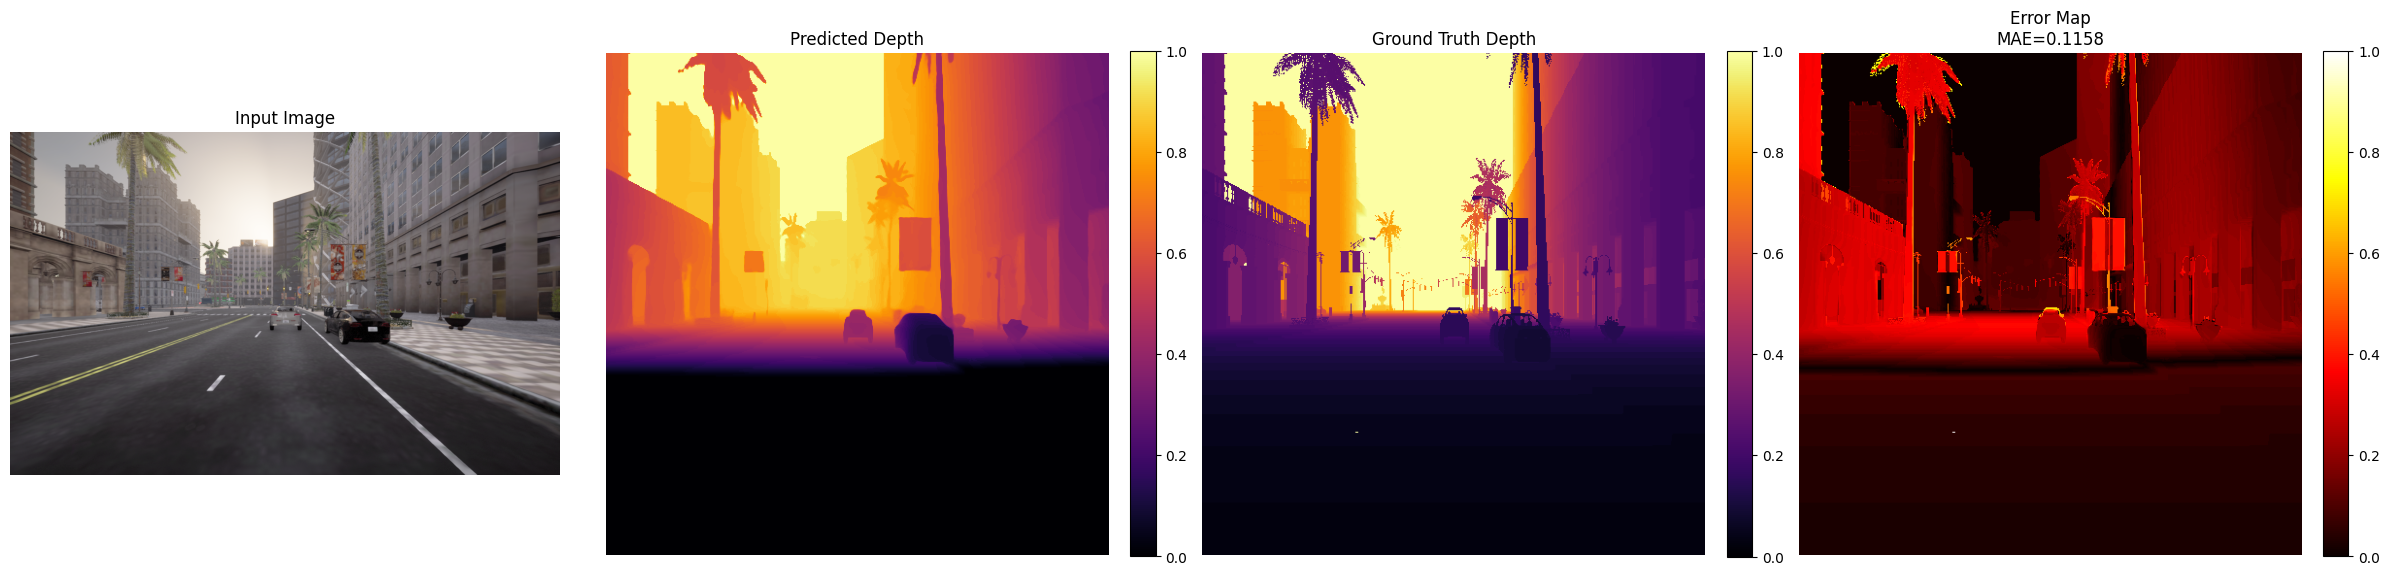

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ---- Paths ----
example_name = os.listdir(output_folder)[0]

# ---- Load Images ----
img = cv2.cvtColor(cv2.imread(os.path.join(input_folder, example_name)), cv2.COLOR_BGR2RGB)
pred_depth = cv2.imread(os.path.join(output_folder, example_name), cv2.IMREAD_GRAYSCALE).astype(np.float32)
gt_depth = np.array(Image.open(os.path.join(gt_folder, example_name))).astype(np.float32)

# ---- Resize GT to Match Prediction ----
if gt_depth.shape != pred_depth.shape:
    gt_depth = cv2.resize(gt_depth, (pred_depth.shape[1], pred_depth.shape[0]), interpolation=cv2.INTER_NEAREST)

# ---- Global Depth Scale ----
# CARLA depth maps are usually in meters, with max depth ~80m
MAX_DEPTH = 80.0

# ---- Normalize to Same Scale ----
gt_norm = np.clip(gt_depth / MAX_DEPTH, 0, 1)


# ---- Predicted Depth (Monocular - flipped) ----
pred_norm = 1 - np.clip(pred_depth / MAX_DEPTH, 0, 1)


# ---- Absolute Error Map ----
abs_error = np.abs(pred_norm - gt_norm)
mae_value = abs_error.mean()

# ---- Visualization ----
plt.figure(figsize=(24, 6))
titles = [
    "Input Image",
    "Predicted Depth",
    "Ground Truth Depth",
    f"Error Map\nMAE={mae_value:.4f}"
]
images = [img, pred_norm, gt_norm, abs_error]
cmaps = [None, "inferno", "inferno", "hot"]

for i, (im, t, cmap) in enumerate(zip(images, titles, cmaps)):
    plt.subplot(1, 4, i + 1)
    imshow = plt.imshow(im, cmap=cmap, vmin=0, vmax=1)
    plt.title(t)
    plt.axis("off")
    if cmap is not None:
        plt.colorbar(imshow, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Qualitative Analysis: Best vs Worst Predictions

- **Best Example (Lowest MAE):** shows good performance in structured, textured regions.
- **Worst Example (Highest MAE):** highlights failure cases in low-texture or distant regions.


Best Example: 515.png (MAE=0.0947)
Worst Example: 491.png (MAE=0.1632)


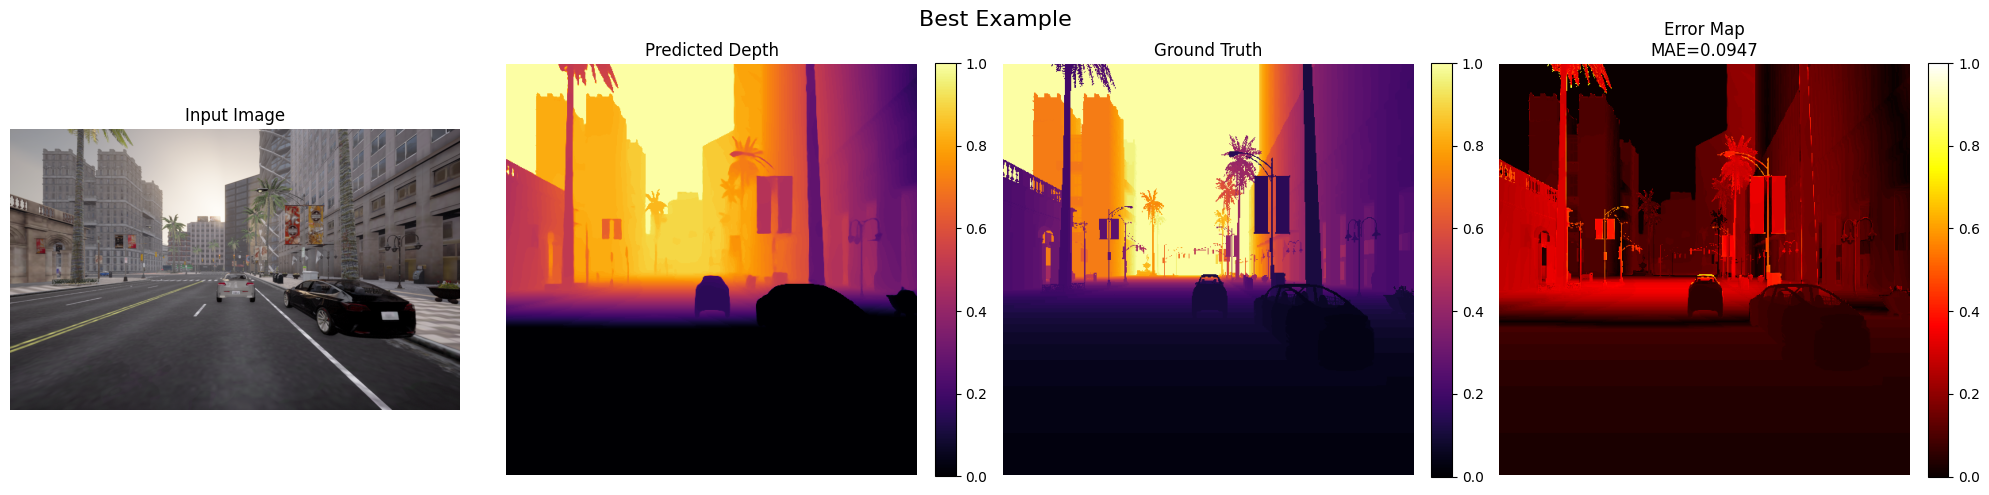

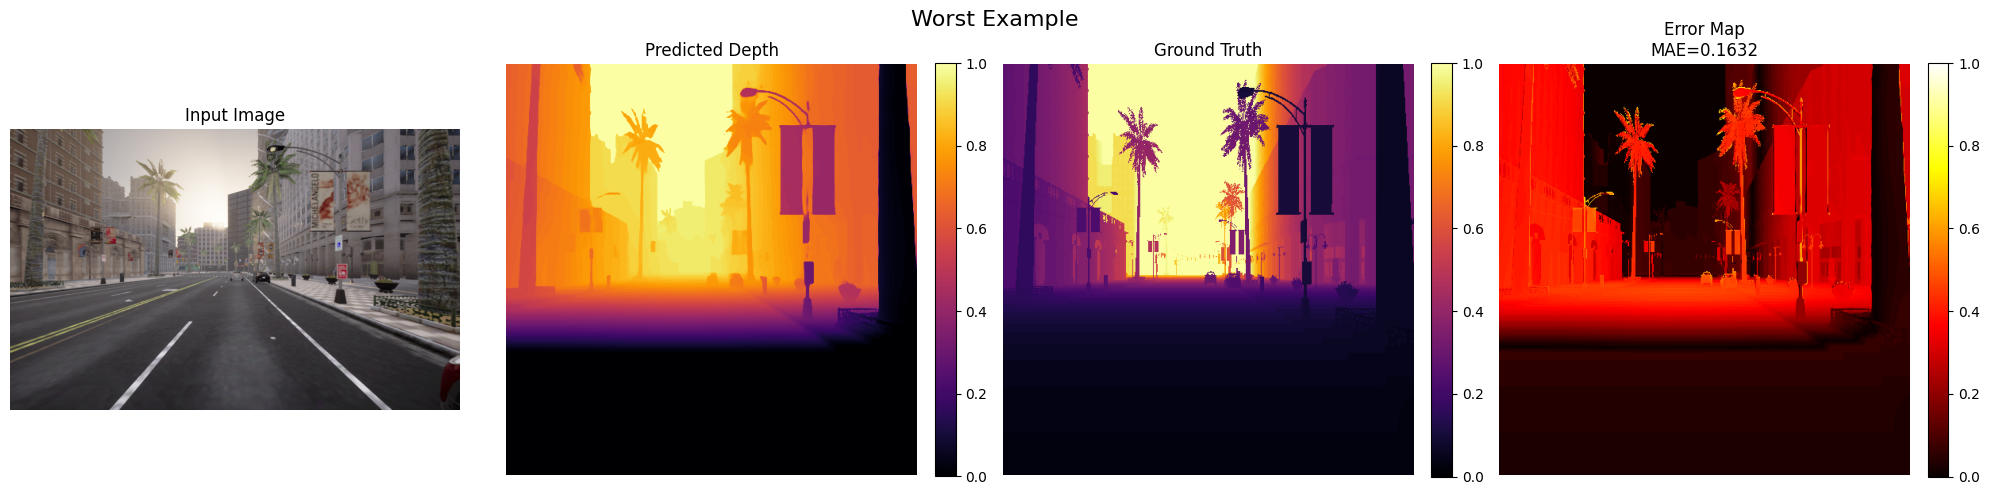

In [10]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ---- Parameters ----
MAX_DEPTH = 80.0  # CARLA ~80m
device = "cuda" if torch.cuda.is_available() else "cpu"

MAEs = []
file_names = []

# ---- Calculate MAE for Each Image ----
for fname in os.listdir(output_folder):
    if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
        continue

    # Load predicted depth (uint8 saved previously)
    pred_depth = cv2.imread(os.path.join(output_folder, fname), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    gt_path = os.path.join(gt_folder, fname)

    if not os.path.exists(gt_path):
        continue

    # Load Ground Truth
    gt_depth = np.array(Image.open(gt_path)).astype(np.float32)

    # Resize GT to match pred size
    if gt_depth.shape != pred_depth.shape:
        gt_depth = cv2.resize(gt_depth, (pred_depth.shape[1], pred_depth.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Normalize (Monocular flipped)
    gt_norm = np.clip(gt_depth / MAX_DEPTH, 0, 1)
    pred_norm = 1 - np.clip(pred_depth / MAX_DEPTH, 0, 1)

    # MAE
    mae = np.mean(np.abs(pred_norm - gt_norm))
    MAEs.append(mae)
    file_names.append(fname)

# ---- Best & Worst ----
best_idx = int(np.argmin(MAEs))
worst_idx = int(np.argmax(MAEs))

best_file = file_names[best_idx]
worst_file = file_names[worst_idx]

print(f"Best Example: {best_file} (MAE={MAEs[best_idx]:.4f})")
print(f"Worst Example: {worst_file} (MAE={MAEs[worst_idx]:.4f})")

# ---- Visualization Function ----
def plot_example(example_name, mae_value, title="Example"):
    img = cv2.cvtColor(cv2.imread(os.path.join(input_folder, example_name)), cv2.COLOR_BGR2RGB)
    pred_depth = cv2.imread(os.path.join(output_folder, example_name), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    gt_depth = np.array(Image.open(os.path.join(gt_folder, example_name))).astype(np.float32)

    if gt_depth.shape != pred_depth.shape:
        gt_depth = cv2.resize(gt_depth, (pred_depth.shape[1], pred_depth.shape[0]), interpolation=cv2.INTER_NEAREST)

    gt_norm = np.clip(gt_depth / MAX_DEPTH, 0, 1)
    pred_norm = 1 - np.clip(pred_depth / MAX_DEPTH, 0, 1)
    abs_error = np.abs(pred_norm - gt_norm)

    plt.figure(figsize=(20, 5))
    titles = [
        "Input Image",
        "Predicted Depth",
        "Ground Truth",
        f"Error Map\nMAE={mae_value:.4f}"
    ]
    images = [img, pred_norm, gt_norm, abs_error]
    cmaps = [None, "inferno", "inferno", "hot"]

    for i, (im, t, cmap) in enumerate(zip(images, titles, cmaps)):
        plt.subplot(1, 4, i + 1)
        imshow = plt.imshow(im, cmap=cmap, vmin=0, vmax=1)
        plt.title(t)
        plt.axis("off")
        if cmap is not None:
            plt.colorbar(imshow, fraction=0.046, pad=0.04)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# ---- Plot Best & Worst ----
plot_example(best_file, MAEs[best_idx], title="Best Example")
plot_example(worst_file, MAEs[worst_idx], title="Worst Example")


## Quantitative Results Distribution

The histogram below shows the distribution of MAE and RMSE across the test set,  
highlighting the overall consistency and error spread of the model.


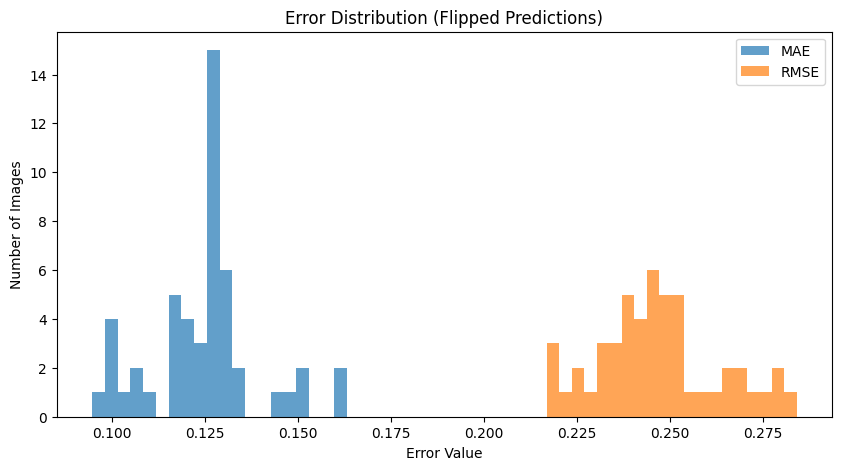

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(MAEs, bins=20, alpha=0.7, label="MAE")
plt.hist(RMSEs, bins=20, alpha=0.7, label="RMSE")
plt.xlabel("Error Value")
plt.ylabel("Number of Images")
plt.title("Error Distribution (Flipped Predictions)")
plt.legend()
plt.show()
